<a href="https://colab.research.google.com/github/karineha1/Comp551-Assignment3-GR64/blob/main/assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# McGill COMP551, MINI-PROJECT 3: Odd-One-Out Image Groups
Student names (IDs) - **Kaggle team name**


# Kaggle Competition
Training and test data are available as part of the assignment in the `datasets` folder. To participate in the competition you should upload a CSV file containing your predicted labels for the entire test data to Kaggle.

The test data is divided in half. You receive the correct labels for the first half (in the `datasets` folder), so that you can evaluate your model in this notebook on that part of the test set. You then submit your solution for the entire test set to Kaggle. The final evaluation is based on your predictions for the second half of the test set (private leaderboard). We have step-by-step explanation in the final section of this notebook.


# Report
The purpose of this notebook is for you to provide a concise high level code of your methodology. That is, you need to include all steps necessary to reproduce your results. Please include a high-level explanation of the implementation so that we can understand what you're trying to achieve in each piece of the code. You can import python code here if needed, in order to keep the notebook concise.

**Note:** You need to submit this notebook where you have run all the cells as part of the assignment. **We should not need to rerun your code since this can take a long time.**


## Step 1 — The Dataset
Use the following code to load the data using the npy files. We have **3,000 training examples**, where each example is a group of **5 grayscale images** (each 32×32). In each group:
- **4 images** share a hidden common property, and
- **1 image** is the **outlier**.

You do **not** have access to the underlying attributes. Your task is to learn to identify the **index** of the outlier image (a 5-class classification problem, with labels in {0, 1, 2, 3, 4}). The label is printed above each group shown below.

In [37]:
# Code to import the datasets since our team shares our work on Github.

import os
import subprocess

# Check if the code is running in Google Colab.
in_google_colab = 'google.colab' in str(__import__('sys').modules)

if in_google_colab:
    # Define the repository URL and name.
    repo_url = "https://github.com/karineha1/Comp551-Assignment3-GR64"
    repo_name = "Comp551-Assignment3-GR64"
    repo_root = f"/content/{repo_name}"

    # If the repository has not been cloned yet, clone it and change the current working directory.
    if not os.path.exists(repo_root):
        subprocess.run(["git", "clone", repo_url, repo_root], check=True)

    os.chdir(repo_root)

# Verify that the necessary dataset files are accessible after cloning/changing directory.
assert os.path.exists("datasets/x_train.npy"), "x_train.npy not found."
assert os.path.exists("datasets/y_train.npy"), "y_train.npy not found."
assert os.path.exists("datasets/x_test.npy"),  "x_test.npy not found."
assert os.path.exists("datasets/y_test.npy"),  "y_test.npy not found."

# Print the current working directory to confirm the setup.
print("Working directory:", os.getcwd())

Working directory: /content/Comp551-Assignment3-GR64


In [38]:
import numpy as np
import matplotlib.pyplot as plt

x = np.load('datasets/x_train.npy')  # (3000, 5, 32, 32) — 3000 groups of 5 images each
y = np.load('datasets/y_train.npy')  # (3000,) — index of the outlier image in each group (0-4)

print(f'Training set: {x.shape[0]} groups, each with {x.shape[1]} images of size {x.shape[2]}x{x.shape[3]}')
print(f'Labels: values in {np.unique(y)}')

Training set: 3000 groups, each with 5 images of size 32x32
Labels: values in [0 1 2 3 4]


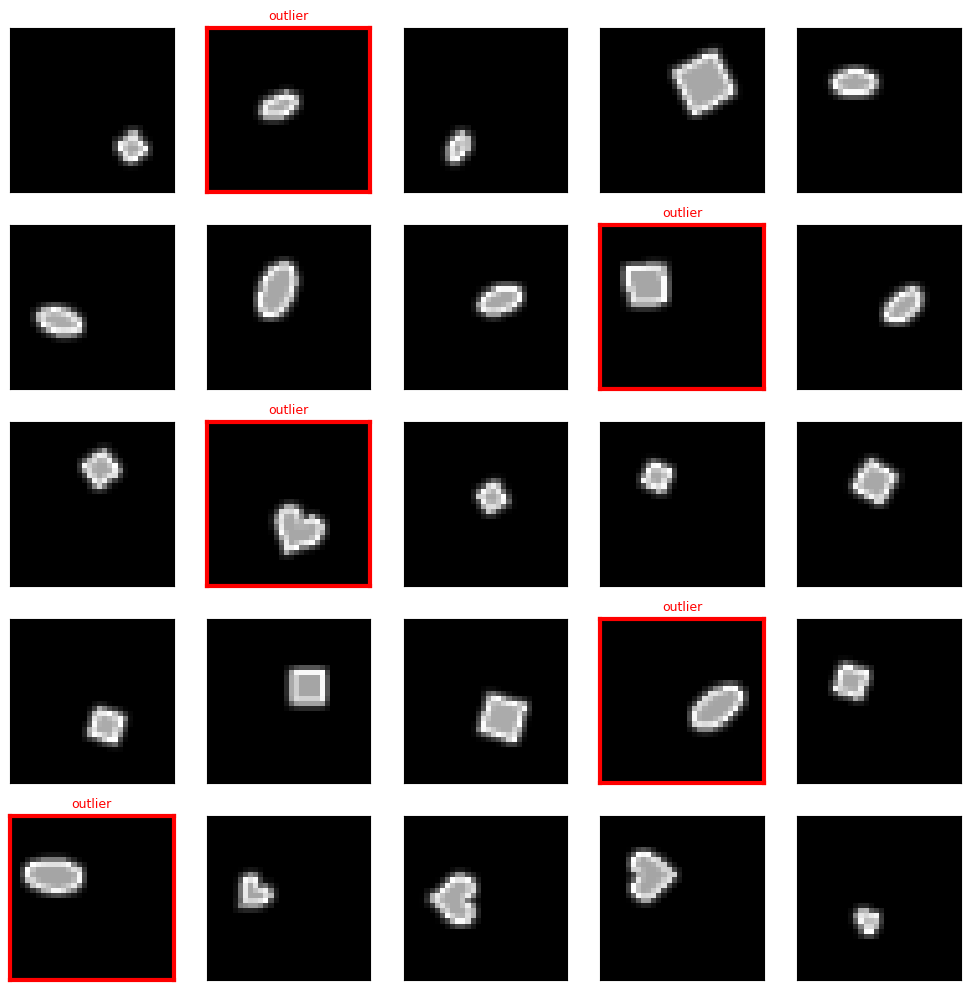

In [39]:
def plot_groups(x, y, num_groups=5):
    """Plot groups of 5 images. The outlier is highlighted with a red border."""
    fig, axes = plt.subplots(num_groups, 5, figsize=(10, 2 * num_groups))
    for i in range(num_groups):
        for j in range(5):
            axes[i, j].imshow(x[i, j], cmap='gray')
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
            if j == y[i]:
                for spine in axes[i, j].spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(3)
                axes[i, j].set_title('outlier', color='red', fontsize=9)
    plt.tight_layout()
    plt.show()

plot_groups(x, y, num_groups=5)

## Step 2 — Example: Logistic Regression Baseline
Below we apply a simple logistic regression to the flattened input as a demonstration. This model treats the entire group of 5 images as one flat vector and does not use any deep learning.

Note that **random chance** for this 5-class problem is **20%** (1/5).
As you can see, the logistic regression baseline performs close to random chance — you are expected to do significantly better using a deep learning model implemented in PyTorch (or Jax/TensorFlow).

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

features = x.reshape(x.shape[0], -1)  # flatten each group of 5 images into a single vector
labels = y

x_train, x_val, y_train, y_val = train_test_split(features, labels, test_size=0.33, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(x_train, y_train)

predictions = clf.predict(x_val)
accuracy = accuracy_score(y_val, predictions)
print(f'The validation accuracy of the baseline model is {accuracy * 100:.2f}%')

The validation accuracy of the baseline model is 19.39%


## Step 3 — Your Model
This is the main part of your report. Provide your model implementation, training code, and explanation below. Details should include the architecture, choice of hyperparameters, and any preprocessing or augmentation you applied. If you performed a hyperparameter search, explain it here.

**Important:** Your model must have at most **25,000** trainable parameters. You **must** uncomment and run the cell below to print and verify the parameter count. This count must also appear in your report.

In [41]:
## your implementation goes here!



In [42]:
# ============================================================
# REQUIRED: Print the number of trainable parameters in your model.
# Replace `model` with the name of your PyTorch model.
# This cell MUST appear with its output in your submitted notebook.
# ============================================================

# total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f'Total trainable parameters: {total_params:,}')
# assert total_params <= 25_000, f'Model too large! {total_params:,} > 25,000'

Using device: cuda
Train size: 3200 | Val size: 800
Epoch  1/70  Train loss: 1.6105  Val loss: 1.6123  Val acc: 18.6%
Epoch  2/70  Train loss: 1.6093  Val loss: 1.6119  Val acc: 19.5%
Epoch  3/70  Train loss: 1.6081  Val loss: 1.6130  Val acc: 21.5%
Epoch  4/70  Train loss: 1.6071  Val loss: 1.6113  Val acc: 20.9%
Epoch  5/70  Train loss: 1.6040  Val loss: 1.6106  Val acc: 22.2%
Epoch  6/70  Train loss: 1.5976  Val loss: 1.5986  Val acc: 26.6%
Epoch  7/70  Train loss: 1.5846  Val loss: 1.5743  Val acc: 32.0%
Epoch  8/70  Train loss: 1.5594  Val loss: 1.6804  Val acc: 26.0%
Epoch  9/70  Train loss: 1.5332  Val loss: 1.5086  Val acc: 38.0%
Epoch 10/70  Train loss: 1.5217  Val loss: 1.5221  Val acc: 34.5%
Epoch 11/70  Train loss: 1.4872  Val loss: 1.4762  Val acc: 37.4%
Epoch 12/70  Train loss: 1.4435  Val loss: 1.6853  Val acc: 29.2%
Epoch 13/70  Train loss: 1.3816  Val loss: 1.3640  Val acc: 43.4%
Epoch 14/70  Train loss: 1.2738  Val loss: 1.5609  Val acc: 34.4%
Epoch 15/70  Train loss:

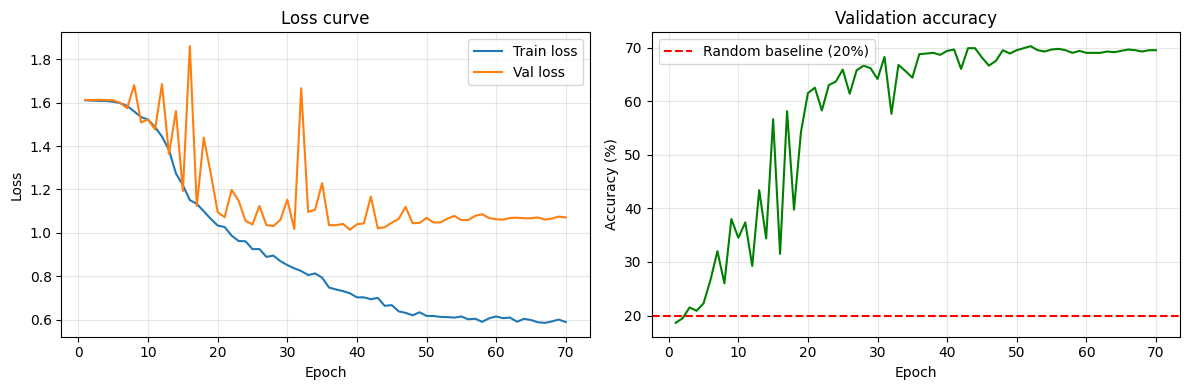

In [65]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

# ── Device ────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Hyperparameters ───────────────────────────────────────────────────
BATCH_SIZE   = 64
EPOCHS       = 70 #50
LR           = 1e-3
WEIGHT_DECAY = 1e-4
VAL_SPLIT    = 0.2
SEED         = 42

torch.manual_seed(SEED)


# ── Model ─────────────────────────────────────────────────────────────
# Architecture: shared CNN encoder + group-aware scoring head.
#
# Each of the 5 images in a group is passed through the same CNN
# (shared weights) to produce a 32-dim embedding. The head then scores
# each image by comparing its embedding to the group mean — the image
# that deviates most from the group is predicted as the outlier.
#
# AdaptiveAvgPool2d replaces Flatten+Linear to avoid a large parameter
# cost from flattening spatial features. This keeps us well under 25K.

class OddOneOutNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Shared encoder: (1, 32, 32) → 32-dim embedding
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # → (16, 32, 32)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → (16, 16, 16)

            nn.Conv2d(16, 32, kernel_size=3, padding=1), # → (32, 16, 16)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → (32, 8, 8)

            nn.Conv2d(32, 16, kernel_size=3, padding=1), # → (16, 8, 8)
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((2, 2)),                 # → (16, 2, 2) = 64 values

            nn.Flatten(),                                 # → 64
        )

        # Scoring head: takes each image's embedding concatenated with
        # the group mean embedding → scalar score per image.
        # Input dim = 32 (own emb) + 32 (group mean) = 64
        self.head = nn.Sequential(
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        B = x.shape[0]

        # Encode all 5 images independently with shared weights
        imgs = x.view(B * 5, 1, 32, 32)           # (B*5, 1, 32, 32)
        embs = self.encoder(imgs).view(B, 5, -1)   # (B, 5, 32)

        # Concatenate each embedding with the group mean for context
        mean_emb = embs.mean(dim=1, keepdim=True)  # (B, 1, 32)
        mean_emb = mean_emb.expand(B, 5, -1)       # (B, 5, 32)
        combined = torch.cat([embs, mean_emb], dim=-1)  # (B, 5, 64)

        # Score each image — highest score = predicted outlier
        logits = self.head(combined).squeeze(-1)   # (B, 5)
        return logits



# ── Data preparation ──────────────────────────────────────────────────
# Normalize to zero mean and unit variance across the entire training set
x_mean = x.mean()
x_std  = x.std()
x_norm = (x - x_mean) / (x_std + 1e-8)

# allo banane
# Load and normalize the labeled test data
x_test      = np.load('datasets/x_test.npy')
x_test_norm = (x_test - x_mean) / (x_std + 1e-8)

x_test_labeled = x_test_norm[:1000]
y_test_labeled = np.load('datasets/y_test.npy')

# Combine with training data → 4000 groups total
X_all = torch.tensor(np.concatenate([x_norm, x_test_labeled], axis=0), dtype=torch.float32)
y_all = torch.tensor(np.concatenate([y, y_test_labeled], axis=0), dtype=torch.long)

dataset = TensorDataset(X_all, y_all)
# allo banane

# Convert to tensors
X_tensor = torch.tensor(x_norm, dtype=torch.float32)  # (3000, 5, 32, 32)
y_tensor  = torch.tensor(y, dtype=torch.long)          # (3000,)

# Train / validation split
#dataset    = TensorDataset(X_tensor, y_tensor)
val_size   = int(VAL_SPLIT * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train size: {train_size} | Val size: {val_size}")


# ── Initialize model, optimizer, loss ─────────────────────────────────
model     = OddOneOutNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

# Learning rate scheduler: reduces LR by 0.5 if val loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)


# ── Training loop ─────────────────────────────────────────────────────
train_loss_history = []
val_loss_history   = []
val_acc_history    = []

for epoch in range(EPOCHS):

    # — Training phase —
    model.train()
    train_loss_accum = 0.0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss   = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_loss_accum += loss.item()

    train_loss = train_loss_accum / len(train_loader)
    train_loss_history.append(train_loss)

    # — Validation phase —
    model.eval()
    val_loss_accum = 0.0
    correct = 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss   = criterion(output, target)
            val_loss_accum += loss.item()
            correct += (output.argmax(1) == target).sum().item()

    val_loss = val_loss_accum / len(val_loader)
    val_acc  = correct / val_size
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    # Step the scheduler based on validation loss
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1:>2}/{EPOCHS}  "
          f"Train loss: {train_loss:.4f}  "
          f"Val loss: {val_loss:.4f}  "
          f"Val acc: {val_acc*100:.1f}%")


# ── Training curves ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, EPOCHS+1), train_loss_history, label="Train loss")
ax1.plot(range(1, EPOCHS+1), val_loss_history,   label="Val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss curve")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, EPOCHS+1), [a*100 for a in val_acc_history], color="green")
ax2.axhline(y=20, color='red', linestyle='--', label="Random baseline (20%)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Validation accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [66]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')
assert total_params <= 25_000, f'Model too large! {total_params:,} > 25,000'

Total trainable parameters: 13,713


## Step 4 — Accuracy Metrics and CSV Submission to Kaggle
At minimum, you **must** report in your submitted notebook:
1. The **number of trainable parameters** (printed in Step 3 above).
2. Your accuracy on the **first half of the test set** (public leaderboard).

**This accuracy must match your public leaderboard score on Kaggle.** If it does not, your leaderboard submission is discarded.

Below we show this evaluation for the logistic regression baseline. Note that the baseline accuracy is close to **random chance (20%)** — you should aim to do much better.

In [67]:
x_test = np.load('datasets/x_test.npy')        # (2000, 5, 32, 32) — 2000 test groups
x_test_half = x_test[:1000]                     # first half: you have the true labels
y_test_half = np.load('datasets/y_test.npy')    # (1000,) — true labels for the first half only

print(f'Test set: {x_test.shape[0]} groups total')
print(f'Public half: {x_test_half.shape[0]} groups (labels provided)')
print(f'Private half: {x_test.shape[0] - x_test_half.shape[0]} groups (labels hidden)\n')

predictions = clf.predict(x_test_half.reshape(x_test_half.shape[0], -1))
accuracy = accuracy_score(y_test_half, predictions)
print(f'Public test accuracy (should match public leaderboard): {accuracy * 100:.2f}%')

Test set: 2000 groups total
Public half: 1000 groups (labels provided)
Private half: 1000 groups (labels hidden)

Public test accuracy (should match public leaderboard): 20.90%


In [54]:
# ============================================================
# REQUIRED: Print your model's accuracy on the public test half.
# This number MUST match your public leaderboard score on Kaggle.
# Replace the code below with your own model's predictions.
# ============================================================

# your_predictions = ...  # your model's predictions on x_test_half
# your_accuracy = accuracy_score(y_test_half, your_predictions)
# print(f'Public test accuracy (must match Kaggle public leaderboard): {your_accuracy * 100:.2f}%')

In [70]:
# Apply the same normalization used during training
x_test      = np.load('datasets/x_test.npy')
x_test_norm = (x_test - x_mean) / (x_std + 1e-8)
x_test_half_norm = x_test_norm[:1000]
y_test_half = np.load('datasets/y_test.npy')

model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(x_test_half_norm, dtype=torch.float32).to(device)
    your_predictions = model(X_test_tensor).argmax(1).cpu().numpy()

your_accuracy = accuracy_score(y_test_half, your_predictions)
print(f'Public test accuracy (must match Kaggle public leaderboard): {your_accuracy * 100:.2f}%')

Public test accuracy (must match Kaggle public leaderboard): 71.50%


### Generating the CSV for Kaggle Submission
In order to submit your results to Kaggle you need to provide your predictions in CSV format. The code below shows how to do this for the logistic regression baseline above. You can use the same method for your submission.

Note that you need to submit your result for the **entire test set** of size **2,000**. Your accuracy on the first 1,000 will show on the public leaderboard and the remaining 1,000 are on the private leaderboard that will be revealed when the competition is over. Submit the `predicted_labels.csv` to the Kaggle competition!

In [71]:
import pandas as pd

def generate_csv_kaggle(y):
    indexes = np.arange(len(y))
    csv_labels = np.concatenate((indexes.reshape(-1, 1), y.reshape(-1, 1)), axis=1)
    df = pd.DataFrame(csv_labels, columns=['Id', 'Category'])
    df['Id'] = df['Id'].astype(str)
    df['Category'] = df['Category'].astype(str)
    df.to_csv('predicted_labels.csv', index=False)

# Baseline prediction for the entire test set (2000 groups)
yh_test = clf.predict(x_test.reshape(x_test.shape[0], -1))
generate_csv_kaggle(yh_test)
print(f'Saved {len(yh_test)} predictions to predicted_labels.csv')

Saved 2000 predictions to predicted_labels.csv


In [72]:
x_test_full_norm = (x_test - x_mean) / (x_std + 1e-8)

model.eval()
with torch.no_grad():
    X_full_tensor = torch.tensor(x_test_full_norm, dtype=torch.float32).to(device)
    yh_test = model(X_full_tensor).argmax(1).cpu().numpy()

generate_csv_kaggle(yh_test)
print(f'Saved {len(yh_test)} predictions to predicted_labels.csv')

Saved 2000 predictions to predicted_labels.csv
